# Identifying Exoplanets with Deep Learning
## Step 1: Importing & Verifying the Dataset
We begin by checking that our TFRecord data files (train, val, test) are present in the `./tfrecord` directory.


In [2]:
# =============================================================================
# STEP 1: IMPORT LIBRARIES & VERIFY DATASET FILES
# =============================================================================
# We need 'os' to interact with the file system (listing files),
# and 'tensorflow' as our deep learning framework.
# =============================================================================

import os
import tensorflow as tf

# Path to the folder containing our TFRecord dataset files
# (should be in the same directory as this notebook)
tfrecord_path = './tfrecord'

# Verify the dataset files exist by listing everything in the folder
print("Files in the folder:")
try:
    files = os.listdir(tfrecord_path)
    for file in files:
        print(file)
except FileNotFoundError:
    print(f"No folder found at: {tfrecord_path}")


Files in the folder:
train-00007-of-00008
train-00006-of-00008
test-00000-of-00001
val-00000-of-00001
train-00000-of-00008
train-00001-of-00008
train-00004-of-00008
train-00005-of-00008
train-00003-of-00008
train-00002-of-00008


## Step 2: Define the TFRecord Parsing Function
Each TFRecord example contains three features:
- `global_view` — a 2001-point light curve (zoomed out, full orbital period)
- `local_view` — a 201-point light curve (zoomed in, around the transit event)
- `av_training_set` — a string label (`'PC'` = Planet Candidate, anything else = Not a Planet)

This function decodes each raw example and converts the label into a binary `0` or `1`.


In [3]:
# =============================================================================
# STEP 2: DEFINE THE TFRECORD PARSING FUNCTION
# =============================================================================
# TFRecord files store data as serialized binary protocol buffers.
# This function tells TensorFlow how to decode each example back into
# usable tensors (light curves + label).
# =============================================================================

def parse_tfrecord_fn(example):
    """
    Parses a single serialized TFRecord example into input features and a label.

    Returns:
        features (dict): {'global_view': Tensor(2001,), 'local_view': Tensor(201,)}
        label (Tensor):  [1.0] if Planet Candidate ('PC'), [0.0] otherwise
    """

    # Define the schema: what fields exist and their shapes/types
    feature_description = {
        'global_view': tf.io.FixedLenFeature([2001], tf.float32),   # Full-orbit light curve
        'local_view': tf.io.FixedLenFeature([201], tf.float32),     # Transit-zoomed light curve
        'av_training_set': tf.io.FixedLenFeature([], tf.string)     # Label string ('PC' or other)
    }

    # Decode the binary example using the schema above
    parsed_features = tf.io.parse_single_example(example, feature_description)

    # Extract the two light curve views
    global_view = parsed_features['global_view']
    local_view = parsed_features['local_view']

    # Convert the string label to binary:
    #   'PC' (Planet Candidate) → 1.0
    #   Anything else           → 0.0
    raw_label = parsed_features['av_training_set']
    is_planet = tf.cast(tf.equal(raw_label, b'PC'), tf.float32)
    label = tf.reshape(is_planet, [1])  # Reshape to (1,) for compatibility with loss function

    return {'global_view': global_view, 'local_view': local_view}, label

print("Parsing function ready")


Parsing function ready


## Step 3: Load, Parse & Batch the Datasets
We collect the file paths for train/val/test splits, read them as raw TFRecord datasets, apply our parsing function, and group the data into batches of 64.

> **Note:** `.repeat()` is applied only to the training set so it can loop across multiple epochs.


In [4]:
# =============================================================================
# STEP 3: LOAD, PARSE & BATCH THE DATASETS
# =============================================================================
# 1. Collect file paths for each split (train / val / test)
# 2. Read the raw binary TFRecord files
# 3. Apply the parsing function to decode each example
# 4. Group examples into mini-batches of 64 for efficient GPU processing
# =============================================================================

# --- 3a: Build lists of file paths for each data split ---
train_files = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'train' in f]
val_files   = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'val' in f]
test_files  = [os.path.join(tfrecord_path, f) for f in os.listdir(tfrecord_path) if 'test' in f]

# --- 3b: Create raw TFRecord datasets (still serialized binary at this stage) ---
raw_train_dataset = tf.data.TFRecordDataset(train_files)
raw_val_dataset   = tf.data.TFRecordDataset(val_files)
raw_test_dataset  = tf.data.TFRecordDataset(test_files)

# --- 3c: Parse and batch ---
batch_size = 64  # Number of samples per training step

# .map()    → decode each binary example using our parsing function
# .batch()  → group decoded examples into batches of 64
# .repeat() → loop the training data infinitely (needed because we set steps_per_epoch manually)
train_dataset = raw_train_dataset.map(parse_tfrecord_fn).batch(batch_size).repeat()
val_dataset   = raw_val_dataset.map(parse_tfrecord_fn).batch(batch_size)
test_dataset  = raw_test_dataset.map(parse_tfrecord_fn).batch(batch_size)

print("Datasets are loaded, parsed, and batched")


Datasets are loaded, parsed, and batched


## Step 4: Build the Dual-Input CNN Architecture
The model uses **two parallel 1D-CNN branches** — one for the global view and one for the local view — which are then merged and fed into a dense classifier.

**Architecture Overview:**


In [6]:
# =============================================================================
# STEP 4: BUILD THE DUAL-INPUT 1D-CNN MODEL
# =============================================================================
# This model follows the AstroNet architecture concept:
#   - Two separate CNN branches process the global and local light curves
#   - Their learned features are concatenated (merged)
#   - A fully connected layer makes the final planet/not-planet decision
#
# Total trainable parameters: ~1.1 million
# =============================================================================

from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model


def build_exoplanet_cnn():
    """
    Builds and returns a dual-input 1D-CNN for exoplanet transit classification.

    Inputs:
        global_view: (2001, 1) — full orbital period light curve
        local_view:  (201, 1)  — zoomed-in transit event light curve

    Output:
        Sigmoid probability [0, 1] — likelihood of being a planet
    """

    # ----- Input Layers -----
    # Each input is a 1D time-series with 1 channel (brightness over time)
    global_input = Input(shape=(2001, 1), name='global_view')
    local_input  = Input(shape=(201, 1),  name='local_view')

    # ----- Global View Branch -----
    # Conv1D extracts local patterns (dips/transits) from the full light curve
    x_global = Conv1D(filters=16, kernel_size=5, activation='relu')(global_input)  # → (1997, 16)
    x_global = MaxPooling1D(pool_size=2, strides=2)(x_global)                     # → (998, 16)  — halves the length
    x_global = Conv1D(filters=32, kernel_size=5, activation='relu')(x_global)      # → (994, 32)  — deeper features
    x_global = MaxPooling1D(pool_size=2, strides=2)(x_global)                     # → (497, 32)  — halves again
    x_global = Flatten()(x_global)                                                 # → (15904,)   — flatten for dense layer

    # ----- Local View Branch -----
    # Same architecture applied to the zoomed-in transit window
    x_local = Conv1D(filters=16, kernel_size=5, activation='relu')(local_input)    # → (197, 16)
    x_local = MaxPooling1D(pool_size=2, strides=2)(x_local)                       # → (98, 16)
    x_local = Conv1D(filters=32, kernel_size=5, activation='relu')(x_local)        # → (94, 32)
    x_local = MaxPooling1D(pool_size=2, strides=2)(x_local)                       # → (47, 32)
    x_local = Flatten()(x_local)                                                   # → (1504,)

    # ----- Merge & Classify -----
    merged = Concatenate()([x_global, x_local])                  # → (17408,) — combine both branches
    dense  = Dense(64, activation='relu')(merged)                 # → (64,)    — learn combined patterns
    output = Dense(1, activation='sigmoid', name='label')(dense)  # → (1,)     — probability of being a planet

    # Assemble the full model with both inputs and one output
    model = Model(inputs=[global_input, local_input], outputs=output)
    return model


# Build and display the model architecture
test_model = build_exoplanet_cnn()
test_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ global_view         │ (None, 2001, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_view          │ (None, 201, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1997, 16)  │         96 │ global_view[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 197, 16)   │         96 │ local_view[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 998, 16)   │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 98, 16)    │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 994, 32)   │      2,592 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 94, 32)    │      2,592 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 497, 32)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 47, 32)    │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 15904)     │          0 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1504)      │          0 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 17408)     │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │  1,114,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (Dense)       │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,119,617 (4.27 MB)

 Trainable params: 1,119,617 (4.27 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train an Ensemble of 10 CNN Models
Instead of relying on a single model, we train **10 independent copies** of the same architecture. Each starts with different random weights, so they learn slightly different patterns. Later, we'll average their predictions for a more robust result.

**Training Config:**
- **Optimizer:** Adam (learning rate = 0.00001 — intentionally low for stable convergence)
- **Loss:** Binary Cross-Entropy (standard for binary classification)
- **Epochs:** Up to 100, with Early Stopping (patience = 12)
- **Each model is saved to disk** as `model_copy_X.keras`

 *This cell takes a while to run — ~10 models × ~100 epochs each.*


In [8]:
# =============================================================================
# STEP 5: ENSEMBLE TRAINING — TRAIN 10 INDEPENDENT MODEL COPIES
# =============================================================================
# Why an ensemble?
#   - Each model starts with different random weight initialization
#   - They each learn slightly different decision boundaries
#   - Averaging their predictions reduces individual model bias/variance
#   - Result: more reliable and stable classifications
#
# Early Stopping monitors validation loss and halts training if it
# stops improving for 12 consecutive epochs, then restores the best weights.
#
# All trained models are saved into the './trained_models/' directory.
# =============================================================================

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Create a dedicated folder to store all trained model files
models_dir = './trained_models'
os.makedirs(models_dir, exist_ok=True)  # Creates the folder if it doesn't already exist

# List to store all 10 trained model objects
trained_models = []

print("Starting Ensemble Training locally on Mac with 0.00001 Learning Rate...")

for i in range(10):
    print(f"\n--- Training Model Copy {i+1} of 10 ---")

    # --- Early Stopping Callback ---
    # Monitors validation loss; if it doesn't improve for 12 epochs,
    # training stops and the best weights are automatically restored.
    early_stopper = EarlyStopping(
        monitor='val_loss',          # Metric to watch
        patience=12,                 # Number of epochs to wait before stopping
        restore_best_weights=True,   # Roll back to the best epoch's weights
        verbose=1
    )

    # --- Build a fresh model (new random weights each time) ---
    current_model = build_exoplanet_cnn()

    # --- Compile with a very low learning rate for fine-grained learning ---
    # A small LR (1e-5) means the model takes tiny steps, which prevents
    # overshooting the optimal solution — especially important with small datasets.
    custom_adam = Adam(learning_rate=0.00001)
    current_model.compile(
        optimizer=custom_adam,
        loss='binary_crossentropy',   # Standard loss for binary classification
        metrics=['accuracy']
    )

    # --- Train the model ---
    history = current_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=100,                   # Max epochs (early stopping may cut it short)
        steps_per_epoch=197,          # Number of batches per epoch (dataset size / batch_size)
        callbacks=[early_stopper],
        verbose=1
    )

    # --- Save the trained model into the dedicated folder ---
    trained_models.append(current_model)
    save_path = os.path.join(models_dir, f'model_copy_{i+1}.keras')
    current_model.save(save_path)

    # --- Log which epoch had the best weights ---
    best_epoch = early_stopper.best_epoch + 1 if early_stopper.best_epoch is not None else "Final"
    print(f" Model {i+1} training complete! Saved to {save_path}. Best weights from Epoch {best_epoch}.")

print("\n All 10 models have successfully finished training!")
print(f" Models saved in: {models_dir}/")


Starting Ensemble Training locally on Mac with 0.00001 Learning Rate...

--- Training Model Copy 1 of 10 ---
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7650 - loss: 0.5084 - val_accuracy: 0.7745 - val_loss: 0.4676
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7708 - loss: 0.4475 - val_accuracy: 0.7745 - val_loss: 0.4171
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7814 - loss: 0.3964 - val_accuracy: 0.8043 - val_loss: 0.3666
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8243 - loss: 0.3511 - val_accuracy: 0.8380 - val_loss: 0.3261
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8549 - loss: 0.3154 - val_accuracy: 0.8647 - val_loss: 0.2951
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8758 - loss: 0.2880 - val_accuracy: 0.8818 - val_loss: 0.2719
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8896 - loss: 0.2671 - val_accuracy: 0.8945 - val_l

## Step 6: Evaluate the Ensemble on the Test Set
We load all 10 saved models from `./trained_models/`, have each one predict on the **unseen test data**, then average their predictions. A star is classified as a planet if the averaged probability exceeds 0.5.


Loading trained models from disk...
  Loaded: ./trained_models/model_copy_1.keras
  Loaded: ./trained_models/model_copy_2.keras
  Loaded: ./trained_models/model_copy_3.keras
  Loaded: ./trained_models/model_copy_4.keras
  Loaded: ./trained_models/model_copy_5.keras
  Loaded: ./trained_models/model_copy_6.keras
  Loaded: ./trained_models/model_copy_7.keras
  Loaded: ./trained_models/model_copy_8.keras
  Loaded: ./trained_models/model_copy_9.keras
  Loaded: ./trained_models/model_copy_10.keras

Gathering predictions from all 10 models on the Test Data...
  Model 1 predicting...


/Users/adityasharma/Documents/Repo/Exoplanet-transit-classifier/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  Model 2 predicting...
  Model 3 predicting...
  Model 4 predicting...
  Model 5 predicting...
  Model 6 predicting...
  Model 7 predicting...
  Model 8 predicting...
  Model 9 predicting...
  Model 10 predicting...

--- FINAL ENSEMBLE TEST SCORES ---
Accuracy:  93.96%
Precision: 86.91%
Recall:    86.67%



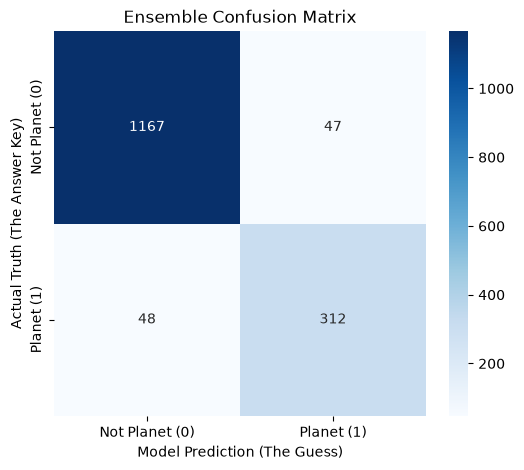

In [9]:
# =============================================================================
# STEP 6: ENSEMBLE EVALUATION ON THE TEST SET
# =============================================================================
# Each of the 10 models independently predicts on the test data.
# We then average their probability outputs (soft voting) and apply
# a 0.5 threshold to produce the final binary prediction.
#
# This ensemble approach smooths out individual model quirks and
# produces a more reliable classification.
# =============================================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 6a: Extract the ground truth labels from the test dataset ---
true_labels = []
for data, label in test_dataset:
    true_labels.extend(label.numpy())
true_labels = np.array(true_labels)

# --- 6b: Load all 10 trained models from the dedicated folder ---
models_dir = './trained_models'
trained_models = []
print("Loading trained models from disk...")
for i in range(1, 11):
    model_path = os.path.join(models_dir, f'model_copy_{i}.keras')
    trained_models.append(tf.keras.models.load_model(model_path))
    print(f"  Loaded: {model_path}")

# --- 6c: Collect predictions from all 10 models ---
all_predictions = []
print("\nGathering predictions from all 10 models on the Test Data...")

for i, model in enumerate(trained_models):
    print(f"  Model {i+1} predicting...")
    predictions = model.predict(test_dataset, verbose=0)  # Returns probabilities [0, 1]
    all_predictions.append(predictions)

# --- 6d: Ensemble averaging (soft voting) ---
# Average the 10 probability arrays element-wise
averaged_probabilities = np.mean(all_predictions, axis=0)

# Apply threshold: probability > 0.5 → Planet (1), else Not Planet (0)
final_predictions = (averaged_probabilities > 0.5).astype(float)

# --- 6e: Calculate performance metrics ---
acc  = accuracy_score(true_labels, final_predictions)
prec = precision_score(true_labels, final_predictions)
rec  = recall_score(true_labels, final_predictions)

print("\n--- FINAL ENSEMBLE TEST SCORES ---")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%\n")

# --- 6f: Plot the Confusion Matrix ---
cm = confusion_matrix(true_labels, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Planet (0)', 'Planet (1)'],
            yticklabels=['Not Planet (0)', 'Planet (1)'])
plt.ylabel('Actual Truth (The Answer Key)')
plt.xlabel('Model Prediction (The Guess)')
plt.title('Ensemble Confusion Matrix')
plt.show()


## Step 7: ROC Curve — How Well Does the Model Separate Planets from Non-Planets?
The **ROC (Receiver Operating Characteristic)** curve plots the True Positive Rate vs. False Positive Rate at every possible threshold. The **AUC (Area Under the Curve)** summarizes this:
- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guessing (the dashed diagonal line)


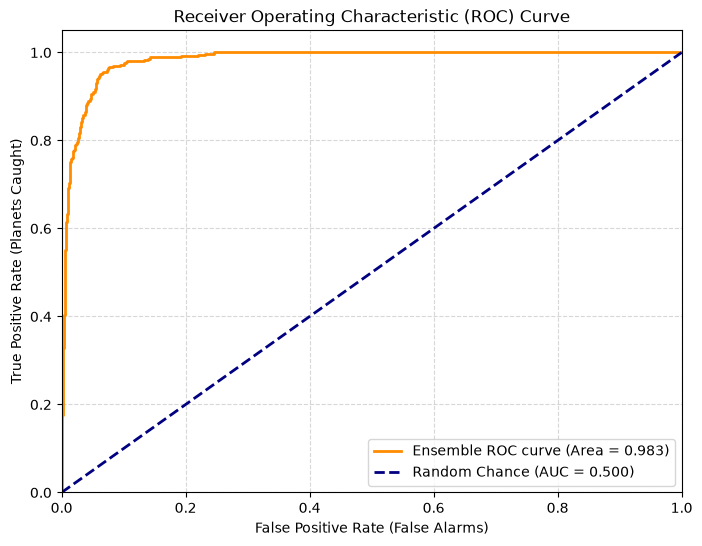

In [10]:
# =============================================================================
# STEP 7: ROC CURVE — RECEIVER OPERATING CHARACTERISTIC
# =============================================================================
# The ROC curve shows the trade-off between catching real planets
# (True Positive Rate) and raising false alarms (False Positive Rate)
# at every possible decision threshold.
#
# AUC (Area Under the Curve) gives a single number summary:
#   1.0 = perfect separation | 0.5 = no better than coin flip
# =============================================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate the ROC curve points using the averaged ensemble probabilities
fpr, tpr, thresholds = roc_curve(true_labels, averaged_probabilities)
roc_auc = auc(fpr, tpr)  # Area under the ROC curve

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Ensemble ROC curve (Area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Chance (AUC = 0.500)')  # Diagonal baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Planets Caught)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Step 8: t-SNE Brain Map — Visualizing How the AI "Thinks"
We extract the activations from the model's **second-to-last layer** (the 64-neuron Dense layer) — this is the model's internal representation of each star.

**t-SNE** (t-distributed Stochastic Neighbor Embedding) then compresses these 64-dimensional "brain patterns" down to 2D so we can visualize them. If the model has learned well, planets (blue) and non-planets (red) should form **distinct clusters**.


Extracting brain cell patterns...
Calculating 2D geometry with t-SNE (this may take a minute)...


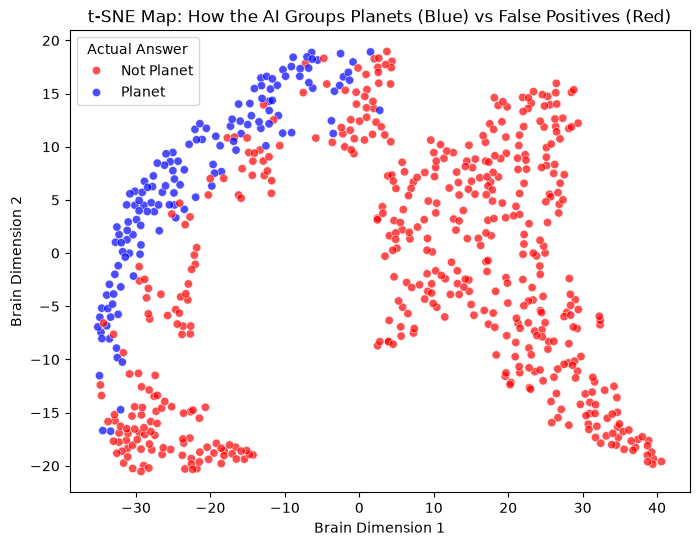

In [11]:
# =============================================================================
# STEP 8: t-SNE BRAIN MAP — VISUALIZE THE MODEL'S INTERNAL REPRESENTATIONS
# =============================================================================
# Instead of looking at the model's final yes/no answer, we peek inside
# its "brain" — specifically the 64-neuron Dense layer just before the
# output. Each star gets encoded as a 64-dimensional feature vector.
#
# t-SNE compresses these 64 dimensions into 2D for visualization.
# Clear separation between clusters = the model has learned meaningful patterns.
# =============================================================================

from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# --- 8a: Build a sub-model that outputs the 64-neuron dense layer ---
# We take the first trained model and "cut" it at the Dense(64) layer
best_model = trained_models[0]

# Automatically find the 64-neuron dense layer by searching backwards
dense_layer = None
for layer in reversed(best_model.layers):
    if 'dense' in layer.name.lower() and layer.units == 64:
        dense_layer = layer
        break

# Fallback: use second-to-last layer if not found by name
if dense_layer is None:
    dense_layer = best_model.layers[-2]

# Create a new model that outputs the internal representations (not predictions)
brain_model = Model(inputs=best_model.input, outputs=dense_layer.output)

# --- 8b: Feed stars through the sub-model to extract brain patterns ---
test_features = []
test_labels_list = []

print("Extracting brain cell patterns...")

# Ensure the dataset is in the correct parsed format
try:
    sample_batch = next(iter(test_dataset.take(1)))
    if isinstance(sample_batch[0], tf.Tensor) and sample_batch[0].dtype == tf.string:
        safe_dataset = test_dataset.map(parse_tfrecord_fn).batch(64)
    else:
        safe_dataset = test_dataset
except Exception:
    safe_dataset = test_dataset.map(parse_tfrecord_fn).batch(64)

# Loop through 10 batches (up to 640 stars)
for batch_data, batch_labels in safe_dataset.take(10):

    # Ensure dictionary keys match what the Keras model expects
    if isinstance(batch_data, dict):
        fixed_batch = {
            'global_view': batch_data.get('global_input', batch_data.get('global_view')),
            'local_view':  batch_data.get('local_input',  batch_data.get('local_view'))
        }
    else:
        fixed_batch = batch_data

    # Get the 64-dimensional internal representation for each star
    features = brain_model.predict(fixed_batch, verbose=0)
    test_features.extend(features)
    test_labels_list.extend(batch_labels.numpy())

test_features = np.array(test_features)
test_labels_list = np.array(test_labels_list)

# --- 8c: Reduce 64 dimensions → 2 dimensions using t-SNE ---
print("Calculating 2D geometry with t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(test_features)

# --- 8d: Plot the Brain Map ---
plt.figure(figsize=(8, 6))

# Flatten arrays to strictly 1D to prevent plotting issues
x_coords   = np.ravel(tsne_results[:, 0])
y_coords   = np.ravel(tsne_results[:, 1])
flat_labels = np.ravel(test_labels_list)

sns.scatterplot(
    x=x_coords,
    y=y_coords,
    hue=flat_labels,
    palette=['red', 'blue'],  # Red = Not Planet, Blue = Planet
    alpha=0.7
)

plt.title("t-SNE Map: How the AI Groups Planets (Blue) vs False Positives (Red)")
plt.xlabel("Brain Dimension 1")
plt.ylabel("Brain Dimension 2")

# Fix legend labels to be human-readable
handles, previous_labels = plt.gca().get_legend_handles_labels()
if handles:
    plt.legend(handles=handles, labels=["Not Planet", "Planet"], title="Actual Answer")

plt.show()


## Step 9: Robustness Test — Flipped Light Curves
To test if the model truly learned transit physics (not just memorized patterns), we **horizontally flip every light curve** (reverse the time axis) and re-test the ensemble.

If the model is robust, accuracy should remain high — because a transit dip looks the same whether read left-to-right or right-to-left. This uses **all data** (train + val + test) combined.


Preparing the 100% Flipped Universal Dataset...
Testing the ensemble on 15737 reversed stars...
  Model 1 predicting...


/Users/adityasharma/Documents/Repo/Exoplanet-transit-classifier/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  Model 2 predicting...
  Model 3 predicting...
  Model 4 predicting...
  Model 5 predicting...
  Model 6 predicting...
  Model 7 predicting...
  Model 8 predicting...
  Model 9 predicting...
  Model 10 predicting...

--- 100% FLIPPED UNIVERSAL TEST SCORES ---
Accuracy:  93.89%
Precision: 86.04%
Recall:    87.47%



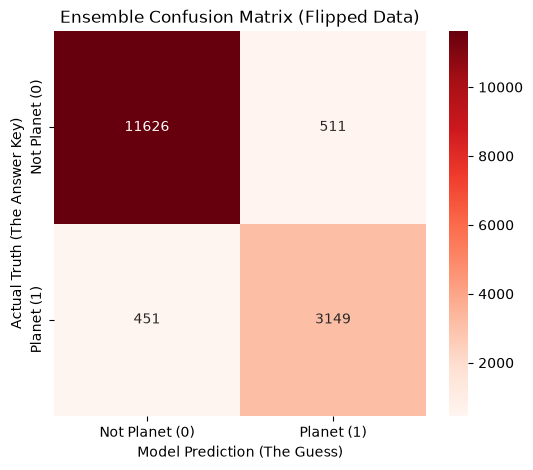

In [12]:
# =============================================================================
# STEP 9: ROBUSTNESS TEST — 100% FLIPPED LIGHT CURVES
# =============================================================================
# A transit dip is symmetric in time, so flipping the light curve
# horizontally should NOT fool a well-trained model.
#
# We combine ALL data (train + val + test), flip every light curve,
# and have the ensemble predict on this reversed data.
# If accuracy stays high → the model learned real transit physics.
# If accuracy drops hard → the model may have memorized artifacts.
# =============================================================================

import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 9a: Combine ALL data files into one massive dataset ---
all_files = train_files + val_files + test_files
raw_all_dataset = tf.data.TFRecordDataset(all_files)


# --- 9b: Define the horizontal flip transformation ---
def force_flip_lightcurves(features, label):
    """
    Reverses both light curves along the time axis.
    No randomness — every single example is flipped 100% of the time.
    """
    features['global_view'] = tf.reverse(features['global_view'], axis=[0])
    features['local_view']  = tf.reverse(features['local_view'],  axis=[0])
    return features, label


# --- 9c: Parse, flip, and batch the entire dataset ---
print("Preparing the 100% Flipped Universal Dataset...")
flipped_dataset = raw_all_dataset.map(parse_tfrecord_fn).map(force_flip_lightcurves).batch(batch_size)

# --- 9d: Extract the true answer key ---
true_labels_flipped = []
for data, label in flipped_dataset:
    true_labels_flipped.extend(label.numpy())
true_labels_flipped = np.array(true_labels_flipped)

# --- 9e: All 10 models take the blind flipped exam ---
all_flipped_predictions = []
print(f"Testing the ensemble on {len(true_labels_flipped)} reversed stars...")

for i, model in enumerate(trained_models):
    print(f"  Model {i+1} predicting...")
    predictions = model.predict(flipped_dataset, verbose=0)
    all_flipped_predictions.append(predictions)

# --- 9f: Ensemble averaging on flipped data ---
averaged_flipped_probabilities = np.mean(all_flipped_predictions, axis=0)
final_flipped_predictions = (averaged_flipped_probabilities > 0.5).astype(float)

# --- 9g: Calculate performance metrics ---
acc  = accuracy_score(true_labels_flipped, final_flipped_predictions)
prec = precision_score(true_labels_flipped, final_flipped_predictions)
rec  = recall_score(true_labels_flipped, final_flipped_predictions)

print("\n--- 100% FLIPPED UNIVERSAL TEST SCORES ---")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%\n")

# --- 9h: Plot confusion matrix ---
cm = confusion_matrix(true_labels_flipped, final_flipped_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',  # Red color to distinguish from normal test
            xticklabels=['Not Planet (0)', 'Planet (1)'],
            yticklabels=['Not Planet (0)', 'Planet (1)'])
plt.ylabel('Actual Truth (The Answer Key)')
plt.xlabel('Model Prediction (The Guess)')
plt.title('Ensemble Confusion Matrix (Flipped Data)')
plt.show()


## Step 10: Training History — Loss & Accuracy Convergence
These plots show how the **last trained model** converged over epochs:
- **Left:** Loss should decrease smoothly for both training and validation
- **Right:** Accuracy should increase and plateau

If the training and validation curves diverge significantly → overfitting.


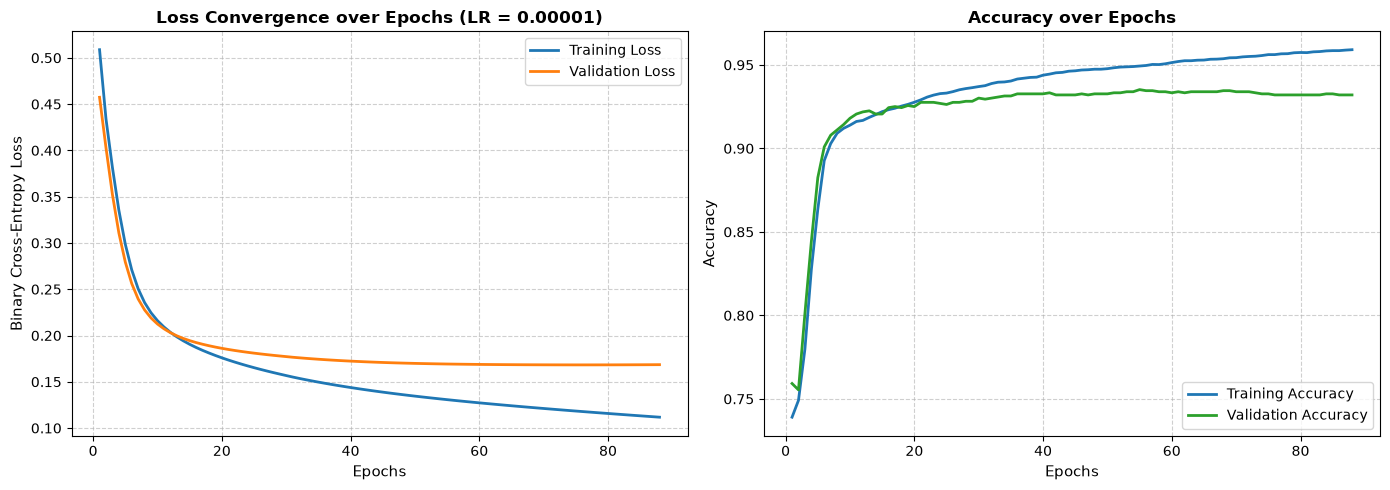

In [13]:
# =============================================================================
# STEP 10: TRAINING HISTORY — LOSS & ACCURACY OVER EPOCHS
# =============================================================================
# The 'history' object from model.fit() stores per-epoch metrics.
# Note: This plots the history of the LAST model trained (Model 10).
# If you need a specific model's history, save it during the training loop.
# =============================================================================

import matplotlib.pyplot as plt

# Check if 'history' is available from the training loop
if 'history' in locals():
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # --- Plot 1: Loss Convergence ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['loss'],
             label='Training Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history.history['val_loss'],
             label='Validation Loss', color='#ff7f0e', lw=2)
    plt.title('Loss Convergence over Epochs (LR = 0.00001)',
              fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Binary Cross-Entropy Loss', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)

    # --- Plot 2: Accuracy Convergence ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['accuracy'],
             label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history.history['val_accuracy'],
             label='Validation Accuracy', color='#2ca02c', lw=2)
    plt.title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Run your training loop to generate the history object first.")
